# 04 · Geoquímica por clases y control RGB

Se leen las paletas constantes de los scripts históricos mediante AST, sin ejecutarlos. Se exige coincidencia de color con la clase declarada y opacidad completa. Se reconstruye la agregación a 1 km solo para aplicar este control adicional; no se modifican los TIFF de A/C.

La coincidencia con la paleta local **no certifica la leyenda oficial ni el medio/extracción**. Se guardan esas limitaciones. Clase 0 válida; NoData no es cero. No se calculan concentraciones, ratios ni logaritmos. Moda y proporciones son representaciones alternativas.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/geoau/features.py').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
import matplotlib.pyplot as plt
from geoau import features as fd

RUN = fd.current_run(ROOT)
print(RUN)
import importlib.metadata
fd.write_json(RUN / 'environment_fase_d.json', {p: importlib.metadata.version(p) for p in ('numpy', 'scipy', 'pyarrow')})

C:\Users\Lenovo\Desktop\PROYECTO IA\Proyecto Con Luis\reports\fase_d\20260908T131414_539995Z


In [2]:
geochemistry, geochemistry_quality = fd.geochemistry(ROOT, RUN)
display(pd.read_csv(RUN / 'geoquimica_rgb_qc.csv'))

Bloque verificado: geochemistry


,element,valid_native_original_land,accepted_native_land,rejected_native_land,modal_changed_vs_C,cells_sufficient_rgb,official_legend_validated
0,Au,1956430,1956430,0,0,488096,False
1,As,1956430,1956430,0,0,488096,False
2,Sb,1950793,1950793,0,0,486473,False
3,Bi,1956430,1956430,0,0,488096,False
4,Hg,1956430,518691,1437739,33820,99178,False
5,Cu,1956430,480301,1476129,24647,97578,False
6,Pb,1954606,500860,1453746,36221,90956,False
7,Zn,1956430,575553,1380877,24012,121689,False
8,W,1956430,666541,1289889,31768,136517,False


In [3]:
display(geochemistry.head())
display(geochemistry_quality.describe())

,cell_id,au_clase_modal,au_proporcion_clase_0,au_proporcion_clase_1,au_proporcion_clase_2,au_proporcion_clase_3,au_proporcion_clase_4,au_proporcion_clase_5,au_proporcion_clase_6,as_clase_modal,...,zn_proporcion_clase_6,zn_proporcion_clase_7,w_clase_modal,w_proporcion_clase_0,w_proporcion_clase_1,w_proporcion_clase_2,w_proporcion_clase_3,w_proporcion_clase_4,w_proporcion_clase_5,w_proporcion_clase_6
0,es_pen_utm30_1km_v1_r0000_c0172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,es_pen_utm30_1km_v1_r0000_c0173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,es_pen_utm30_1km_v1_r0001_c0172,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,es_pen_utm30_1km_v1_r0001_c0173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,es_pen_utm30_1km_v1_r0001_c0174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,geoquimica_au_valid_rgb,geoquimica_as_valid_rgb,geoquimica_sb_valid_rgb,geoquimica_bi_valid_rgb,geoquimica_hg_valid_rgb,geoquimica_cu_valid_rgb,geoquimica_pb_valid_rgb,geoquimica_zn_valid_rgb,geoquimica_w_valid_rgb
count,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000,496855.000000
mean,0.985814,0.985814,0.982954,0.985814,0.261390,0.242109,0.252619,0.290088,0.335924
std,0.112843,0.112843,0.123670,0.112843,0.402863,0.400984,0.397676,0.428414,0.438977
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,0.500000,0.500000,0.500000,0.500000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


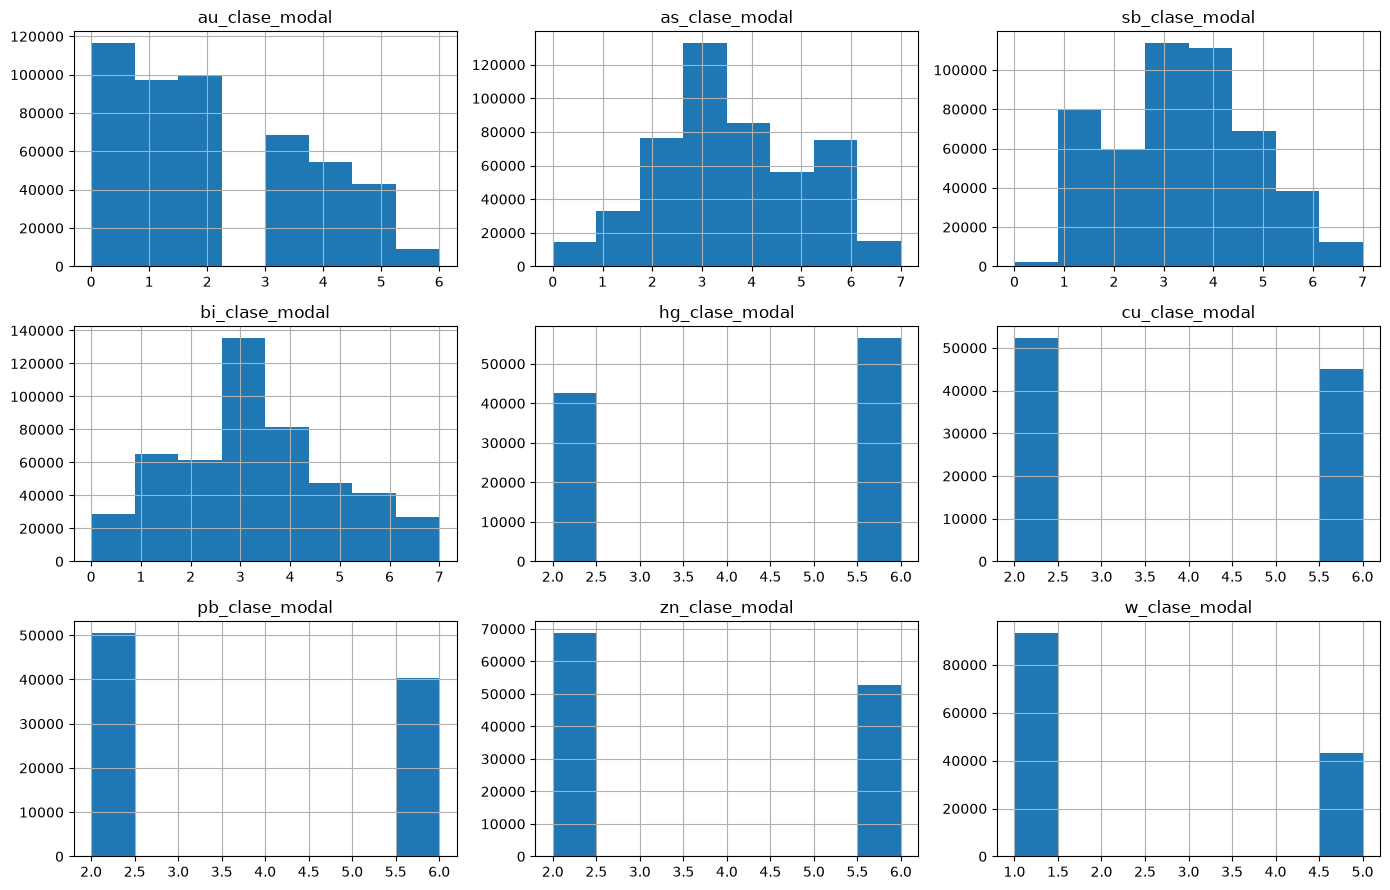

In [4]:
geochemistry.filter(regex='_clase_modal$').hist(figsize=(14, 9), bins=8)
plt.tight_layout()
plt.show()